# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import Ridge
from category_encoders import CatBoostEncoder
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
pd.set_option('display.max_columns', 200)

c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Data

In [8]:
data = pd.read_csv(r'D:\Đại học\01_IS403\Đồ án\model\df_clean_llm_enriched_kaggle.csv')
data.head(2)

,elem_id,title,company_name,company_type,company_star,company_industry,company_size,country,job_expertise,job_description,job_requirements,job_benefits,working_model,overtime_policy,city_group,date_posted_clean,during_days,work_on_saturday,programming_languages_flat,frameworks_libraries_flat,databases_datastores_flat,cloud_devops_flat,platforms_products_flat,methodologies_flat,language_requirements_flat,english_level,seniority_label,experience_years_min,experience_years_max,experience_bucket,req_education_certifications_flat,ai_related,programming_languages_flat_joined,frameworks_libraries_flat_joined,databases_datastores_flat_joined,cloud_devops_flat_joined,platforms_products_flat_joined,methodologies_flat_joined,language_requirements_flat_joined,req_education_certifications_flat_joined
0,1,"01 Lead .NET Developer (C#, .NET, Angular)",Tinh Van Consulting,IT Product,3.6,Software Products and Web Services,51-150,Vietnam,Fullstack Developer,MÔ TẢ VỊ TRÍ\nChúng tôi tìm kiếm một .NET Dev ...,YÊU CẦU\n1. Kỹ năng kỹ thuật bắt buộc\n•\nThàn...,+ Được hưởng mức lương hấp dẫn tương xứng theo...,At office,No OT,Hà Nội,2026-03-25,33,False,"['C#', 'JavaScript']","['Entity Framework', 'LINQ', 'Angular', '.NET'...","['SQL Server', 'Oracle', 'PostgreSQL']","['Azure', 'AWS', 'GitHub Actions', 'Jenkins', ...","['Kafka', 'ERP', 'GraphQL', 'OAuth', 'JWT']","['Waterfall', 'Agile', 'UAT', 'SOLID']",['English'],intermediate,lead,NaN,NaN,unknown,[],False,C#; JavaScript,Entity Framework; LINQ; Angular; .NET; ASP.NET...,SQL Server; Oracle; PostgreSQL,Azure; AWS; GitHub Actions; Jenkins; Docker; K...,Kafka; ERP; GraphQL; OAuth; JWT,Waterfall; Agile; UAT; SOLID,English,NaN
1,2,02 Middle Backend Developer (C# / .NET),VTC Online,IT Product,3.7,Game,51-150,Vietnam,Backend Developer,MỤC TIÊU CÔNG VIỆC\nBackend Engineer .NET Midd...,Bắt buộc\nTối thiểu\n3 năm kinh nghiệm\nphát t...,Thu nhập cạnh tranh theo năng lực và hiệu quả ...,At office,Extra salary for OT,Hà Nội,2026-01-29,50,False,['C#'],['.NET'],"['SQL Server', 'PostgreSQL', 'Redis']","['Docker', 'CI/CD']",[],[],[],unknown,middle,3.0,NaN,3-5,"['Đại học/Cao đẳng các ngành CNTT, Khoa học má...",False,C#,.NET,SQL Server; PostgreSQL; Redis,Docker; CI/CD,NaN,NaN,NaN,"Đại học/Cao đẳng các ngành CNTT, Khoa học máy ..."


# Pre-processing

### Create 'week'

In [9]:
data['date_posted_clean'] = pd.to_datetime(data['date_posted_clean'])
data['week'] = data['date_posted_clean'].dt.isocalendar().week
data['week'].unique()

<IntegerArray>
[13, 5, 7, 10, 15, 12, 9, 8, 14, 6, 11]
Length: 11, dtype: UInt32

### Data Aggregation

In [10]:
def process_and_count_skills(data, col_names, skill_groups):
    # Bỏ các giá trị NaN và tách chuỗi theo dấu ';'
    data['skill_group'] = skill_groups
    data['skill_name'] = data[col_names].astype(str).str.split(';')
    
    # Explode từng kỹ năng ra các dòng riêng biệt
    exploded_df = data.explode('skill_name').dropna(subset=['skill_name'])

    # Chuẩn hóa text
    exploded_df['skill_name'] = exploded_df['skill_name'].str.strip().str.lower()
    
    # Loại bỏ các chuỗi rỗng
    exploded_df = exploded_df[
    exploded_df['skill_name'].notna() &
    (exploded_df['skill_name'] != '') &
    (~exploded_df['skill_name'].isin(['nan', 'none', 'null']))
    ]
    
    # Đếm số lượng theo tuần và tên kỹ năng
    result = exploded_df.groupby(['week', 'skill_group', 'skill_name'])['elem_id'].nunique().reset_index(name='count')

    # % Ai-ralated
    ai_week = data.groupby('week')['ai_related'].apply(
        lambda x: (x == True).sum() / len(x) * 100
    ).reset_index()
    ai_week.columns = ['week', 'ai_percent_week']

    # Total job by week
    total_job_week = data.groupby('week')['elem_id'].nunique().reset_index(name='total_job')

    # Merge data
    result = result.merge(ai_week, on='week', how='left')
    result = result.merge(total_job_week, on='week', how='left')

    exploded_skill = pd.DataFrame(exploded_df[['elem_id', 'skill_name']])
    exploded_skill.drop_duplicates()
    
    return result, exploded_skill

In [11]:
def create_pivot_table(data):
    col_names = ['programming_languages_flat_joined', 'frameworks_libraries_flat_joined', 
                'databases_datastores_flat_joined', 'cloud_devops_flat_joined', 'platforms_products_flat_joined']
    skill_groups = ['program_language', 'framework', 'database', 'cloud_devops', 'platform']
    all_result = []
    all_skill = []

    for col, group in zip(col_names, skill_groups):
        result, skill = process_and_count_skills(data, col, group)
        all_result.append(result)
        all_skill.append(skill)

    all_result = pd.concat(all_result, ignore_index=True)
    all_skill = pd.concat(all_skill, ignore_index=True)
    return all_result, all_skill

In [12]:
# all_skill = pd.concat(all_skill, ignore_index=True)
# all_skill

### Skill Taxonomy

In [ ]:
def get_skill_taxonomy(train, threshold=25):
    # Tổng số lần xuất hiện
    skill_count = train.groupby(['skill_group', 'skill_name'])['count'].sum().reset_index()
    skill_count.columns = ['skill_group', 'skill_name', 'total_count']

    # Số tuần có xuất hiện kỹ năng
    skill_week = train.groupby(['skill_group', 'skill_name'])['week'].nunique().reset_index()
    skill_week.columns = ['skill_group', 'skill_name', 'week_coverage']
    total_week = train['week'].nunique()

    skill_stats = skill_count.merge(skill_week, on=['skill_group', 'skill_name'])
    top_skills = skill_stats[skill_stats['total_count'] > threshold]['skill_name'].tolist()
    rare_steady = skill_stats [
        (skill_stats['total_count'] <= threshold) &
        (skill_stats['week_coverage'] >= 0.6 * total_week)
    ]['skill_name'].tolist()

    return top_skills, rare_steady  

In [14]:
def create_others(data, top_skills, rare_steady):
    keep_skills = set(top_skills + rare_steady)
    mask = ~data['skill_name'].isin(keep_skills)
    data.loc[mask, 'skill_name'] = 'others_' + data.loc[mask, 'skill_group']

    data = data.groupby(['week', 'skill_group', 'skill_name', 'ai_percent_week',
                         'total_job'])['count'].sum().reset_index()
    return data

### Companion Discovery

In [15]:
def discover_companion_skills(data, min_support_pct=0.02, lift_threshold=3):
    # --- Tạo ma trận elem_id x skill ---
    n_jobs = data['elem_id'].nunique()
    min_support = max(20, int(n_jobs * min_support_pct))
    print(f"   Dynamic threshold: {n_jobs} jobs → min_support = {min_support} (≥{min_support_pct*100:.1f}% jobs)")

    pivot = data.pivot_table(
        index='elem_id',
        columns='skill_name',
        aggfunc='size',
        fill_value=0
    )

    # Binary hóa
    binary_matrix = (pivot > 0).astype(int)

    n_transactions = len(binary_matrix)
    companion_dict = {}

    skills = binary_matrix.columns.tolist()

    for i, skill_a in enumerate(skills):
        support_a = binary_matrix[skill_a].sum() / n_transactions

        if binary_matrix[skill_a].sum() < min_support:
            continue

        for skill_b in skills[i+1:]:
            support_b = binary_matrix[skill_b].sum() / n_transactions

            joint_count = ((binary_matrix[skill_a] == 1) & 
                           (binary_matrix[skill_b] == 1)).sum()

            if joint_count < min_support:
                continue

            joint = joint_count / n_transactions

            lift = joint / (support_a * support_b) if (support_a * support_b) > 0 else 0

            if lift >= lift_threshold:
                companion_dict.setdefault(skill_a, []).append((skill_b, lift))
                companion_dict.setdefault(skill_b, []).append((skill_a, lift))

    # Best companion
    best_companion = {}
    for skill, companions in companion_dict.items():
        best = max(companions, key=lambda x: x[1])
        best_companion[skill] = best[0]

    return best_companion

### Cartesian Grid

In [16]:
def create_cartesian_grid(data):
    data = data.copy()

    # Lấy danh sách tuần 
    all_weeks = sorted(data['week'].unique())

    # Lấy danh sách skill + group 
    all_skills = data[['skill_name', 'skill_group']].drop_duplicates()

    # Tạo Cartesian
    grid = pd.MultiIndex.from_product(
        [all_weeks, all_skills['skill_name']],
        names=['week', 'skill_name']
    ).to_frame(index=False)

    # Gắn skill_group 
    grid = grid.merge(all_skills, on='skill_name', how='left')

    # Merge dữ liệu gốc
    result = grid.merge(
        data,
        on=['week', 'skill_name', 'skill_group'],
        how='left'
    )

    # Fill count 
    result['count'] = result['count'].fillna(0).astype(int)

    # Xử lý feature level tuần
    week_features = data[['week', 'ai_percent_week', 'total_job']].drop_duplicates()

    result = result.drop(columns=['ai_percent_week', 'total_job'], errors='ignore')

    result = result.merge(week_features, on='week', how='left')

    #  Sort 
    result = result.sort_values(['week', 'skill_group', 'skill_name']).reset_index(drop=True)

    return result

### Lag Features Generation

In [17]:
def lag_features(data, companion_dict, lags=[1, 2, 3]):
    data = data.sort_values(['skill_name', 'week']).copy()

    for lag in lags:
        # Count lag
        data[f'count_lag{lag}'] = data.groupby('skill_name')['count'].shift(lag)

    # Total_job lag
    data['total_job_lag1'] = data.groupby('skill_name')['total_job'].shift(1)

    # Ai_percent lag
    data['ai_percent_lag1'] = data.groupby('skill_name')['ai_percent_week'].shift(1)

    # Companion lag
    data['companion_name'] = data['skill_name'].map(companion_dict)
    data['companion_lag1'] = 0

    for skill_name in data['skill_name'].unique():
        companion = companion_dict.get(skill_name)
        if companion:
            companion_counts = data[data['skill_name'] == companion][['week', 'count']].copy()
            companion_counts.columns = ['week', 'companion_count']
            companion_counts['companion_lag1'] = companion_counts['companion_count'].shift(1)

            mask = data['skill_name'] == skill_name
            data.loc[mask, 'companion_lag1'] = data.loc[mask, 'week'].map(
                companion_counts.set_index('week')['companion_lag1']
            )

    return data

# Modeling

In [82]:
def modeling_skill(X_train, X_test, y_train, y_test, models, model_names, week):
    Results = pd.DataFrame(columns=['Week', 'Model_name', 'MAE', 'MSE', 'R2'])
    scaler = None
    for model, name in zip(models, model_names):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        new_row = {
            'Week': week,
            'Model_name': name,
            'MAE': mean_absolute_error(y_test, y_pred),
            'MSE': mean_squared_error(y_test, y_pred),
            'R2': r2_score(y_test, y_pred)
        }

        Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)
    return Results

In [19]:
def find_best_model(all_result, metric='R2'):
    weeks = sorted(all_result['Week'].unique())
    last_week = weeks[-1]
    prev_week = weeks[-2]

    pivot_table = all_result.pivot(
        index='Model_name',
        columns='Week',
        values=metric
    )

    pivot_table['Change'] = pivot_table[last_week] - pivot_table[prev_week]
    pivot_table['Stability_Penalty'] = pivot_table['Change'].abs()

    if metric == 'R2':
        best_models = pivot_table.sort_values(
            by=[last_week, 'Stability_Penalty'], 
            ascending=[False, True]
        )
    else:
        best_models = pivot_table.sort_values(
            by=[last_week, 'Stability_Penalty'], 
            ascending=[True, True]
        )

    print(best_models[[prev_week, last_week, 'Change']])
    best_model_name = best_models.index[0]
    return best_model_name

In [20]:
def predict_best_model(model_name, model_dict, X_test, y_test):
    model = model_dict[model_name]
    y_pred = model.predict(X_test)
    print(f'Model: {model_name}')
    print('MAE:', mean_absolute_error(y_test, y_pred))
    print('MSE:', mean_squared_error(y_test, y_pred))
    print('R2:', r2_score(y_test, y_pred))
    return y_pred

In [ ]:
modelRidge = Ridge(
    alpha=1.0,        
    random_state=42
)

modelrfr = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)

modelETR = ExtraTreesRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    n_jobs=-1,
    random_state=42
)

modellbg = lgb.LGBMRegressor(
    n_estimators=500, 
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1, 
    n_jobs=-1,
    random_state=42
)

modelcat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=False,
    random_seed=42
)

modelxgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

In [ ]:
model_poisson = PoissonRegressor(
    alpha=1.0,
    max_iter=1000
)

model_lgb_poisson = lgb.LGBMRegressor(
    objective='poisson', 
    n_estimators=500,
    learning_rate=0.02,
    num_leaves=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

model_xgb_poisson = xgb.XGBRegressor(
    objective='count:poisson',
    n_estimators=500,
    learning_rate=0.02,
    max_depth=2,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

model_cat_poisson = CatBoostRegressor(
    loss_function='Poisson',
    iterations=500,
    learning_rate=0.02,
    depth=2,
    verbose=False,
    random_seed=42
)

In [23]:
def ridge_equation(data):
    intercept = modelRidge.intercept_
    coefficients = modelRidge.coef_
    feature_names = data.columns

    equation = f"y = {intercept:.4f}"
    for coef, name in zip(coefficients, feature_names):
        equation += f" + ({coef:.4f} * {name})"

    print("Phương trình tuyến tính của mô hình Ridge:")
    print(equation)

    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients,
        'Abs_Coefficient': np.abs(coefficients)
    }).sort_values(by='Abs_Coefficient', ascending=False)

    print("\nBảng xếp hạng mức độ quan trọng:")
    print(importance_df[['Feature', 'Coefficient']])

In [24]:
def visualize_shap(model, data):
    explainer = shap.TreeExplainer(model)

    # Tính toán SHAP values cho tập dữ liệu
    shap_values = explainer.shap_values(data)

    # Vẽ biểu đồ SHAP Summary Plot
    plt.figure(figsize=(10, 6))
    plt.title("SHAP Summary Plot: Mức độ và chiều tác động của các biến\n", fontsize=14)
    shap.summary_plot(shap_values, data, show=False)
    plt.tight_layout()
    plt.show()

### Version 1

In [ ]:
def  walk_forward_validation_v1(data, flag_use_companion, n_splits=3):
    weeks = sorted(data['week'].unique())

    all_result_top = []
    all_result_rare = []
    all_result_combined = []

    # Lưu lại model tốt nhất cho top và rare skills
    best_model_top_name = None
    best_model_rare_name = None
    best_model_top = None
    best_model_rare = None
    best_encoder_top = None
    best_encoder_rare = None
    
    # Lưu lại toàn bộ kết quả để tìm best model
    all_week_results_top = []
    all_week_results_rare = []

    for split_idx in range(len(weeks) - n_splits, len(weeks)):
        train_weeks = weeks[:split_idx]
        test_week = weeks[split_idx]

        print(f'======= Test week {test_week} =======')
        
        # Split data
        train_data = data[data['week'].isin(train_weeks)].copy()
        test_data = data[data['week'] == test_week].copy()

        # Pivot table
        train_pivot, train_skill = create_pivot_table(train_data)
        test_pivot,_ = create_pivot_table(test_data)

        # Skill Taxonomy
        top_skills, rare_steady = get_skill_taxonomy(train_pivot, threshold=25)
        print(f'Top skills: {len(top_skills)}')
        print(f'Rare steady skills: {len(rare_steady)}')

        # Companion Discovery
        companion_dict = discover_companion_skills(train_skill, min_support_pct=0.02, lift_threshold=3)
        print(f'Companion relationships: {len(companion_dict)}')

        # Concat train - test
        data_pivot = pd.concat([train_pivot, test_pivot], ignore_index=True)

        # Create Others_
        data_clean = create_others(data_pivot, top_skills, rare_steady)

        # Cartesian grid
        data_clean = create_cartesian_grid(data_clean)

        # Lag Feature
        data_final = lag_features(data_clean, companion_dict, lags=[1, 2, 3])
        lag_cols = [col for col in data_final.columns if 'lag' in col]
        data_final[lag_cols] = data_final[lag_cols].fillna(0)

        # Split train - test
        train_final = data_final[data_final['week'].isin(train_weeks)].copy()
        test_final = data_final[data_final['week'] == test_week].copy()

        # === Modeling top skills ===
        train_top = train_final[~train_final['skill_name'].isin(rare_steady)]
        test_top = test_final[~test_final['skill_name'].isin(rare_steady)]

        y_train_top = train_top['count']
        y_test_top = test_top['count']
        
        if flag_use_companion:
            cols_to_drop = ['count', 'ai_percent_week', 'skill_group', 'total_job']
            X_train_top = train_top.drop(columns=cols_to_drop)
            X_test_top = test_top.drop(columns=cols_to_drop)
            cat_cols_top = ['skill_name', 'companion_name']
        else:
            cat_cols_top = ['skill_name']
            cols_to_drop = ['count', 'ai_percent_week', 'skill_group', 'total_job', 'companion_name', 'companion_lag1']
            X_train_top = train_top.drop(columns=cols_to_drop)
            X_test_top = test_top.drop(columns=cols_to_drop)

        encoder_top = CatBoostEncoder(cols=cat_cols_top)
        X_train_enc_top = encoder_top.fit_transform(X_train_top, y_train_top)
        X_test_enc_top = encoder_top.transform(X_test_top)

        models_top = [modelRidge, modelrfr, modelETR, modellbg, modelcat, modelxgb]
        model_names_top = [
            'Ridge',
            'RandomForestRegressor',
            'ExtraTreesRegressor',
            'LightGBM',
            'CatBoost',
            'XGBoost'
        ]
        
        result_top = modeling_skill(X_train_enc_top, X_test_enc_top, y_train_top, y_test_top, 
                                    models_top, model_names_top, weeks[split_idx])
        all_result_top.append(result_top)
        all_week_results_top.append(result_top)

        # === Modeling rare skills ===
        train_rare = train_final[train_final['skill_name'].isin(rare_steady)]
        test_rare = test_final[test_final['skill_name'].isin(rare_steady)]

        cols_to_drop_rare = ['count', 'ai_percent_week', 'skill_group', 'total_job', 'companion_name', 'companion_lag1']
        X_train_rare = train_rare.drop(columns=cols_to_drop_rare)
        X_test_rare = test_rare.drop(columns=cols_to_drop_rare)
        y_train_rare = train_rare['count']
        y_test_rare = test_rare['count']

        cat_cols_rare = ['skill_name']
        encoder_rare = CatBoostEncoder(cols=cat_cols_rare)
        X_train_enc_rare = encoder_rare.fit_transform(X_train_rare, y_train_rare)
        X_test_enc_rare = encoder_rare.transform(X_test_rare)

        models_rare = [model_poisson, model_lgb_poisson, model_xgb_poisson, model_cat_poisson]
        model_names_rare = [
            'Poisson',
            'LightGBM_Poisson',
            'XGBoost_Poisson',
            'CatBoost_Poisson'
        ]
        
        result_rare = modeling_skill(X_train_enc_rare, X_test_enc_rare, y_train_rare, y_test_rare,
                                     models_rare, model_names_rare, weeks[split_idx])
        all_result_rare.append(result_rare)
        all_week_results_rare.append(result_rare)

        # Lưu lại encoder và data của fold cuối cùng để dùng cho predict tổng thể
        if split_idx == len(weeks) - 1:  
            best_encoder_top = encoder_top
            best_encoder_rare = encoder_rare
            X_train_final_top = X_train_enc_top
            X_test_final_top = X_test_enc_top
            y_train_final_top = y_train_top
            y_test_final_top = y_test_top
            X_train_final_rare = X_train_enc_rare
            X_test_final_rare = X_test_enc_rare
            y_train_final_rare = y_train_rare 
            y_test_final_rare = y_test_rare

    # Gộp kết quả
    all_result_top = pd.concat(all_result_top, ignore_index=True)
    all_result_rare = pd.concat(all_result_rare, ignore_index=True)
    all_week_results_top = pd.concat(all_week_results_top, ignore_index=True)
    all_week_results_rare = pd.concat(all_week_results_rare, ignore_index=True)

    # === Tìm best model cho top skills ===
    print("\n" + "="*50)
    best_model_top_name = find_best_model(all_week_results_top, metric='R2')
    print(f"Best model for TOP skills: {best_model_top_name}")
    
    # === Tìm best model cho rare skills ===
    best_model_rare_name = find_best_model(all_week_results_rare, metric='R2')
    print(f"Best model for RARE skills: {best_model_rare_name}")

    # === Tạo dictionary chứa các model đã train ===
    # Train lại best model trên toàn bộ train data của fold cuối
    model_dict_top = {
        'Ridge': modelRidge,
        'RandomForestRegressor': modelrfr,
        'ExtraTreesRegressor': modelETR,
        'LightGBM': modellbg,
        'CatBoost': modelcat,
        'XGBoost': modelxgb
    }
    
    model_dict_rare = {
        'Poisson': model_poisson,
        'LightGBM_Poisson': model_lgb_poisson,
        'XGBoost_Poisson': model_xgb_poisson,
        'CatBoost_Poisson': model_cat_poisson
    }
    
    # Train best model trên toàn bộ train data
    best_model_top = model_dict_top[best_model_top_name]
    best_model_top.fit(X_train_final_top, y_train_final_top)
    
    best_model_rare = model_dict_rare[best_model_rare_name]
    best_model_rare.fit(X_train_final_rare, y_train_final_rare)
    
    # === Dự đoán tổng thể ===
    print("\n" + "="*50)
    print("Overall prediction using best models:")
    
    y_pred_top = best_model_top.predict(X_test_final_top)
    y_pred_rare = best_model_rare.predict(X_test_final_rare)
    
    y_pred_combined = np.concatenate([y_pred_top, y_pred_rare])
    y_test_combined = np.concatenate([y_test_final_top, y_test_final_rare])
    
    print("\n=== OVERALL PERFORMANCE ===")
    print('MAE:', mean_absolute_error(y_test_combined, y_pred_combined))
    print('MSE:', mean_squared_error(y_test_combined, y_pred_combined))
    print('R2:', r2_score(y_test_combined, y_pred_combined))
    
    # Lưu kết quả tổng thể
    all_result_combined = pd.DataFrame({
        'Model_Type': ['Combined'],
        'Best_Model': [f"{best_model_top_name}+{best_model_rare_name}"],
        'MAE': [mean_absolute_error(y_test_combined, y_pred_combined)],
        'MSE': [mean_squared_error(y_test_combined, y_pred_combined)],
        'R2': [r2_score(y_test_combined, y_pred_combined)]
    })
    
    return all_result_top, all_result_rare, all_result_combined, X_train_final_top, X_train_final_rare, best_encoder_top, best_encoder_rare

### Version 2

In [126]:
def walk_forward_validation_v2(data, flag_use_companion, n_splits=3):
    weeks = sorted(data['week'].unique())

    all_result = []

    # Lưu lại model tốt nhất
    best_model_name = None
    best_model = None
    best_encoder = None
    
    # Lưu lại toàn bộ kết quả để tìm best model
    all_week_results = []

    for split_idx in range(len(weeks) - n_splits, len(weeks)):
        train_weeks = weeks[:split_idx]
        test_week = weeks[split_idx]

        print(f'======= Test week {test_week} =======')
        
        # Split data
        train_data = data[data['week'].isin(train_weeks)].copy()
        test_data = data[data['week'] == test_week].copy()

        # Pivot table
        train_pivot, train_skill = create_pivot_table(train_data)
        test_pivot,_ = create_pivot_table(test_data)

        # Skill Taxonomy (chỉ để xác định, không tách riêng)
        top_skills, rare_steady = get_skill_taxonomy(train_pivot, threshold=25)
        print(f'Top skills: {len(top_skills)}')
        print(f'Rare steady skills: {len(rare_steady)}')

        # Companion Discovery
        companion_dict = discover_companion_skills(train_skill, min_support_pct=0.02, lift_threshold=3)
        print(f'Companion relationships: {len(companion_dict)}')

        # Concat train - test
        data_pivot = pd.concat([train_pivot, test_pivot], ignore_index=True)

        # Create Others_
        data_clean = create_others(data_pivot, top_skills, rare_steady)

        # Cartesian grid
        data_clean = create_cartesian_grid(data_clean)

        # Lag Feature
        data_final = lag_features(data_clean, companion_dict, lags=[1, 2, 3])
        lag_cols = [col for col in data_final.columns if 'lag' in col]
        data_final[lag_cols] = data_final[lag_cols].fillna(0)

        # Split train - test (KHÔNG tách top và rare)
        train_final = data_final[data_final['week'].isin(train_weeks)].copy()
        test_final = data_final[data_final['week'] == test_week].copy()

        # === Modeling ALL skills ===
        y_train = train_final['count']
        y_test = test_final['count']

        if flag_use_companion:
            cols_to_drop = ['count', 'ai_percent_week', 'skill_group', 'total_job']
            X_train = train_final.drop(columns=cols_to_drop)
            X_test = test_final.drop(columns=cols_to_drop)
            cat_cols = ['skill_name', 'companion_name']
        else:
            cat_cols = ['skill_name']
            cols_to_drop = ['count', 'ai_percent_week', 'skill_group', 'total_job', 'companion_name', 'companion_lag1']
            X_train = train_final.drop(columns=cols_to_drop)
            X_test = test_final.drop(columns=cols_to_drop)

        encoder = CatBoostEncoder(cols=cat_cols)
        X_train_enc = encoder.fit_transform(X_train, y_train)
        X_test_enc = encoder.transform(X_test)

        # Dùng danh sách models của top skills (6 models)
        models = [modelRidge, modelrfr, modelETR, modellbg, modelcat, modelxgb]
        model_names = [
            'Ridge',
            'RandomForestRegressor',
            'ExtraTreesRegressor',
            'LightGBM',
            'CatBoost',
            'XGBoost'
        ]
        
        result = modeling_skill(X_train_enc, X_test_enc, y_train, y_test, 
                                models, model_names, weeks[split_idx])
        all_result.append(result)
        all_week_results.append(result)

        # Lưu lại encoder và data của fold cuối cùng
        if split_idx == len(weeks) - 1:  
            best_encoder = encoder
            X_train_final = X_train_enc
            X_test_final = X_test_enc
            y_train_final = y_train
            y_test_final = y_test

    # Gộp kết quả
    all_result = pd.concat(all_result, ignore_index=True)
    all_week_results = pd.concat(all_week_results, ignore_index=True)

    # === Tìm best model ===
    print("\n" + "="*50)
    best_model_name = find_best_model(all_week_results, metric='R2')
    print(f"Best model for ALL skills: {best_model_name}")

    # === Tạo dictionary chứa các model ===
    model_dict = {
        'Ridge': modelRidge,
        'RandomForestRegressor': modelrfr,
        'ExtraTreesRegressor': modelETR,
        'LightGBM': modellbg,
        'CatBoost': modelcat,
        'XGBoost': modelxgb
    }
    
    # Train best model trên toàn bộ train data của fold cuối
    best_model = model_dict[best_model_name]
    best_model.fit(X_train_final, y_train_final)
    
    # === Dự đoán tổng thể ===
    print("\n" + "="*50)
    print("Overall prediction using best model:")
    
    y_pred = best_model.predict(X_test_final)
    
    print("\n=== OVERALL PERFORMANCE ===")
    print('MAE:', mean_absolute_error(y_test_final, y_pred))
    print('MSE:', mean_squared_error(y_test_final, y_pred))
    print('R2:', r2_score(y_test_final, y_pred))
    
    return all_result, best_encoder, X_train_final

# Result

## Version 1

### Use companion

In [83]:
result_top_flag, result_rare_flag, all_result_combined, \
X_train1_flag, X_train2_flag, encoder_top_flag, encoder_rare_flag =  walk_forward_validation_v1(
    data, flag_use_companion=True, n_splits=3
)

======= Test week 13 =======
Top skills: 80
Rare steady skills: 51
   Dynamic threshold: 1015 jobs → min_support = 20 (≥2.0% jobs)
Companion relationships: 65


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 616
[LightGBM] [Info] Number of data points in the train set: 672, number of used features: 9
[LightGBM] [Info] Start training from score 10.800595
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000066 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 424, number of used features: 7
[LightGBM] [Info] Start training from score 0.618495
======= Test week 14 =======
Top skills: 90
Rare steady skills: 37
   Dynamic threshold: 1167 jobs → min_support = 23 (≥2.0% jobs)
Companion relationships: 63


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000048 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 121
[LightGBM] [Info] Number of data points in the train set: 351, number of used features: 7
[LightGBM] [Info] Start training from score 0.544442
======= Test week 15 =======
Top skills: 96
Rare steady skills: 36
   Dynamic threshold: 1329 jobs → min_support = 26 (≥2.0% jobs)
Companion relationships: 64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 710
[LightGBM] [Info] Number of data points in the train set: 1000, number of used features: 9
[LightGBM] [Info] Start training from score 9.827000


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000052 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 123
[LightGBM] [Info] Number of data points in the train set: 380, number of used features: 7
[LightGBM] [Info] Start training from score 0.401950

Week                         14        15    Change
Model_name                                         
Ridge                  0.839108  0.853695  0.014587
XGBoost                0.793343  0.813566  0.020223
CatBoost               0.834075  0.803970 -0.030105
ExtraTreesRegressor    0.859455  0.796792 -0.062663
RandomForestRegressor  0.840791  0.796292 -0.044499
LightGBM               0.834681  0.779679 -0.055002
Best model for TOP skills: Ridge
Week                    14        15    Change
Model_name                                    
LightGBM_Poisson  0.040467  0.106085  0.065618
CatBoost_Poisson -0.017977  0.080756  0.098733
XGBoost_Poisson   0.0115

##### Model 1

In [85]:
pivot_df = result_top_flag.pivot(
    index='Model_name',
    columns='Week',
    values='R2')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,0.624284,0.834075,0.803970
ExtraTreesRegressor,0.594990,0.859455,0.796792
LightGBM,0.580571,0.834681,0.779679
RandomForestRegressor,0.465285,0.840791,0.796292
Ridge,-1.950560,0.839108,0.853695
XGBoost,0.715813,0.793343,0.813566


In [86]:
pivot_df = result_top_flag.pivot(
    index='Model_name',
    columns='Week',
    values='MAE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,5.016904,3.286273,4.357665
ExtraTreesRegressor,5.146865,2.993069,4.596072
LightGBM,5.270241,3.469989,4.652760
RandomForestRegressor,5.672437,3.253982,4.540802
Ridge,17.469070,3.924775,4.061091
XGBoost,4.232476,3.734099,4.447259


In [87]:
pivot_df = result_top_flag.pivot(
    index='Model_name',
    columns='Week',
    values='MSE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,42.200499,23.978968,48.550167
ExtraTreesRegressor,45.490831,20.311137,50.327917
LightGBM,47.110277,23.891415,54.566322
RandomForestRegressor,60.059257,23.008432,50.451805
Ridge,331.407404,23.251705,36.235076
XGBoost,31.919977,29.865412,46.173607


In [88]:
ridge_equation(X_train1_flag)

Phương trình tuyến tính của mô hình Ridge:
y = 0.0632 + (0.2777 * week) + (0.5230 * skill_name) + (0.4746 * count_lag1) + (0.2784 * count_lag2) + (-0.1180 * count_lag3) + (-0.0120 * total_job_lag1) + (-0.0533 * ai_percent_lag1) + (0.0135 * companion_name) + (-0.0235 * companion_lag1)

Bảng xếp hạng mức độ quan trọng:
           Feature  Coefficient
1       skill_name     0.523008
2       count_lag1     0.474614
3       count_lag2     0.278427
0             week     0.277721
4       count_lag3    -0.118017
6  ai_percent_lag1    -0.053279
8   companion_lag1    -0.023524
7   companion_name     0.013535
5   total_job_lag1    -0.011964


##### Model 2

In [89]:
pivot_df = result_rare_flag.pivot(
    index='Model_name',
    columns='Week',
    values='R2')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost_Poisson,0.003814,-0.017977,0.080756
LightGBM_Poisson,0.051157,0.040467,0.106085
Poisson,-0.233614,-0.051842,0.008339
XGBoost_Poisson,0.027741,0.011580,0.065091


In [90]:
pivot_df = result_rare_flag.pivot(
    index='Model_name',
    columns='Week',
    values='MAE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost_Poisson,1.334141,1.111853,1.217527
LightGBM_Poisson,1.288250,1.036309,1.143910
Poisson,1.533751,1.233219,1.270222
XGBoost_Poisson,1.339700,1.116714,1.209883


In [91]:
pivot_df = result_rare_flag.pivot(
    index='Model_name',
    columns='Week',
    values='MSE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost_Poisson,2.674701,2.077448,2.271373
LightGBM_Poisson,2.547587,1.958179,2.208787
Poisson,3.312182,2.146561,2.450309
XGBoost_Poisson,2.610458,2.017130,2.310079


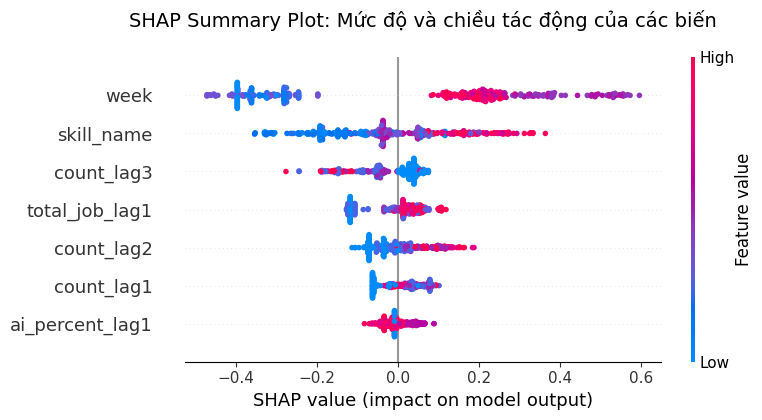

In [92]:
visualize_shap(model_lgb_poisson, X_train2_flag)

##### Combined

In [93]:
all_result_combined

,Model_Type,Best_Model,MAE,MSE,R2
0,Combined,Ridge+LightGBM_Poisson,3.257809,26.865518,0.873785


### Not use companion

In [94]:
result_top, result_rare, all_result_v1, \
X_train1, X_train2, encoder_top, encoder_rare =  walk_forward_validation_v1(
    data, flag_use_companion=False, n_splits=3
)

======= Test week 13 =======
Top skills: 80
Rare steady skills: 51
   Dynamic threshold: 1015 jobs → min_support = 20 (≥2.0% jobs)
Companion relationships: 65


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 359
[LightGBM] [Info] Number of data points in the train set: 672, number of used features: 7
[LightGBM] [Info] Start training from score 10.800595
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000052 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 424, number of used features: 7
[LightGBM] [Info] Start training from score 0.618495
======= Test week 14 =======
Top skills: 90
Rare steady skills: 37
   Dynamic threshold: 1167 jobs → min_support = 23 (≥2.0% jobs)
Companion relationships: 63


...

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000061 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 121
[LightGBM] [Info] Number of data points in the train set: 351, number of used features: 7
[LightGBM] [Info] Start training from score 0.544442
======= Test week 15 =======
Top skills: 96
Rare steady skills: 36
   Dynamic threshold: 1329 jobs → min_support = 26 (≥2.0% jobs)
Companion relationships: 64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000086 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 1000, number of used features: 7
[LightGBM] [Info] Start training from score 9.827000


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000050 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 123
[LightGBM] [Info] Number of data points in the train set: 380, number of used features: 7
[LightGBM] [Info] Start training from score 0.401950

Week                         14        15    Change
Model_name                                         
Ridge                  0.840409  0.854580  0.014171
CatBoost               0.879651  0.830660 -0.048991
XGBoost                0.791616  0.820087  0.028472
RandomForestRegressor  0.832338  0.802661 -0.029677
ExtraTreesRegressor    0.848305  0.795146 -0.053160
LightGBM               0.848038  0.778622 -0.069416
Best model for TOP skills: Ridge
Week                    14        15    Change
Model_name                                    
LightGBM_Poisson  0.040467  0.106085  0.065618
CatBoost_Poisson -0.017977  0.080756  0.098733
XGBoost_Poisson   0.0115

##### Model 1

In [95]:
pivot_df = result_top.pivot(
    index='Model_name',
    columns='Week',
    values='R2')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,0.687080,0.879651,0.830660
ExtraTreesRegressor,0.559033,0.848305,0.795146
LightGBM,0.460787,0.848038,0.778622
RandomForestRegressor,0.456239,0.832338,0.802661
Ridge,-1.941428,0.840409,0.854580
XGBoost,0.750252,0.791616,0.820087


In [96]:
pivot_df = result_top.pivot(
    index='Model_name',
    columns='Week',
    values='MAE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,4.709541,2.922979,4.195450
ExtraTreesRegressor,5.436616,3.176095,4.540718
LightGBM,5.626154,3.313903,4.764218
RandomForestRegressor,5.780969,3.291172,4.483486
Ridge,17.429048,3.911820,4.005819
XGBoost,3.944495,3.665278,4.425634


In [97]:
pivot_df = result_top.pivot(
    index='Model_name',
    columns='Week',
    values='MSE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,35.147271,17.392455,41.940082
ExtraTreesRegressor,49.529458,21.922461,50.735729
LightGBM,60.564538,21.961096,54.828031
RandomForestRegressor,61.075362,24.230017,48.874482
Ridge,330.381645,23.063558,36.015793
XGBoost,28.051785,30.115089,44.558506


In [98]:
ridge_equation(X_train1)

Phương trình tuyến tính của mô hình Ridge:
y = 0.1629 + (0.2770 * week) + (0.5294 * skill_name) + (0.4725 * count_lag1) + (0.2797 * count_lag2) + (-0.1161 * count_lag3) + (-0.0131 * total_job_lag1) + (-0.0531 * ai_percent_lag1)

Bảng xếp hạng mức độ quan trọng:
           Feature  Coefficient
1       skill_name     0.529429
2       count_lag1     0.472451
3       count_lag2     0.279708
0             week     0.276986
4       count_lag3    -0.116066
6  ai_percent_lag1    -0.053116
5   total_job_lag1    -0.013145


##### Model 2

In [99]:
pivot_df = result_rare.pivot(
    index='Model_name',
    columns='Week',
    values='R2')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost_Poisson,0.003814,-0.017977,0.080756
LightGBM_Poisson,0.051157,0.040467,0.106085
Poisson,-0.233614,-0.051842,0.008339
XGBoost_Poisson,0.027741,0.011580,0.065091


In [100]:
pivot_df = result_rare.pivot(
    index='Model_name',
    columns='Week',
    values='MAE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost_Poisson,1.334141,1.111853,1.217527
LightGBM_Poisson,1.288250,1.036309,1.143910
Poisson,1.533751,1.233219,1.270222
XGBoost_Poisson,1.339700,1.116714,1.209883


In [101]:
pivot_df = result_rare.pivot(
    index='Model_name',
    columns='Week',
    values='MSE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost_Poisson,2.674701,2.077448,2.271373
LightGBM_Poisson,2.547587,1.958179,2.208787
Poisson,3.312182,2.146561,2.450309
XGBoost_Poisson,2.610458,2.017130,2.310079


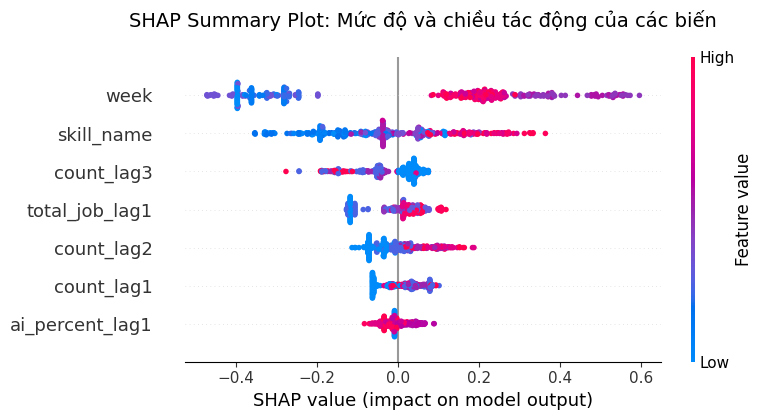

In [102]:
visualize_shap(model_lgb_poisson, X_train2)

##### Combined

In [103]:
all_result_v1

,Model_Type,Best_Model,MAE,MSE,R2
0,Combined,Ridge+LightGBM_Poisson,3.217757,26.706617,0.874532


## Version 2

### Use companion

In [127]:
all_result_flag, encoder_flag, X_train_flag = walk_forward_validation_v2(
    data, flag_use_companion=True
)

======= Test week 13 =======
Top skills: 80
Rare steady skills: 51
   Dynamic threshold: 1015 jobs → min_support = 20 (≥2.0% jobs)
Companion relationships: 65


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000101 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 679
[LightGBM] [Info] Number of data points in the train set: 1096, number of used features: 9
[LightGBM] [Info] Start training from score 7.340328
======= Test week 14 =======
Top skills: 90
Rare steady skills: 37
   Dynamic threshold: 1167 jobs → min_support = 23 (≥2.0% jobs)
Companion relationships: 63


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 698
[LightGBM] [Info] Number of data points in the train set: 1197, number of used features: 9
[LightGBM] [Info] Start training from score 7.660819
======= Test week 15 =======
Top skills: 96
Rare steady skills: 36
   Dynamic threshold: 1329 jobs → min_support = 26 (≥2.0% jobs)
Companion relationships: 64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000169 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 712
[LightGBM] [Info] Number of data points in the train set: 1380, number of used features: 9
[LightGBM] [Info] Start training from score 7.532609

Week                         14        15    Change
Model_name                                         
Ridge                  0.858304  0.891971  0.033667
XGBoost                0.848420  0.850951  0.002531
RandomForestRegressor  0.854772  0.844416 -0.010356
ExtraTreesRegressor    0.879597  0.831158 -0.048438
LightGBM               0.868376  0.827596 -0.040780
CatBoost               0.881798  0.799571 -0.082227
Best model for ALL skills: Ridge

Overall prediction using best model:

=== OVERALL PERFORMANCE ===
MAE: 3.1191293652659966
MSE: 22.994525706172062
R2: 0.8919711093701401


In [128]:
pivot_df = all_result_flag.pivot(
    index='Model_name',
    columns='Week',
    values='R2')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,0.746920,0.881798,0.799571
ExtraTreesRegressor,0.682315,0.879597,0.831158
LightGBM,0.326203,0.868376,0.827596
RandomForestRegressor,0.527591,0.854772,0.844416
Ridge,-0.594615,0.858304,0.891971
XGBoost,0.775422,0.848420,0.850951


In [129]:
pivot_df = all_result_flag.pivot(
    index='Model_name',
    columns='Week',
    values='MAE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,3.506839,2.457643,3.713551
ExtraTreesRegressor,3.749567,2.362923,3.599839
LightGBM,5.111051,2.702084,3.704544
RandomForestRegressor,4.394437,2.664744,3.539242
Ridge,10.995113,3.393889,3.119129
XGBoost,3.365277,2.928289,3.624794


In [130]:
pivot_df = all_result_flag.pivot(
    index='Model_name',
    columns='Week',
    values='MSE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,23.340344,14.621600,42.662352
ExtraTreesRegressor,29.298585,14.893899,35.938878
LightGBM,62.141066,16.281881,36.697154
RandomForestRegressor,43.568063,17.964722,33.116912
Ridge,147.063808,17.527816,22.994526
XGBoost,20.711771,18.750422,31.725822


In [131]:
ridge_equation(X_train_flag)

Phương trình tuyến tính của mô hình Ridge:
y = -1.9583 + (0.2471 * week) + (0.7833 * skill_name) + (0.3979 * count_lag1) + (0.2290 * count_lag2) + (-0.1548 * count_lag3) + (-0.0052 * total_job_lag1) + (-0.0257 * ai_percent_lag1) + (0.0453 * companion_name) + (-0.0160 * companion_lag1)

Bảng xếp hạng mức độ quan trọng:
           Feature  Coefficient
1       skill_name     0.783281
2       count_lag1     0.397936
0             week     0.247118
3       count_lag2     0.228961
4       count_lag3    -0.154838
7   companion_name     0.045281
6  ai_percent_lag1    -0.025664
8   companion_lag1    -0.015988
5   total_job_lag1    -0.005151


### Not use companion

In [132]:
all_result_v2, encoder, X_train = walk_forward_validation_v2(
    data, flag_use_companion=False
)

======= Test week 13 =======
Top skills: 80
Rare steady skills: 51
   Dynamic threshold: 1015 jobs → min_support = 20 (≥2.0% jobs)
Companion relationships: 65


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000087 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 391
[LightGBM] [Info] Number of data points in the train set: 1096, number of used features: 7
[LightGBM] [Info] Start training from score 7.340328
======= Test week 14 =======
Top skills: 90
Rare steady skills: 37
   Dynamic threshold: 1167 jobs → min_support = 23 (≥2.0% jobs)
Companion relationships: 63


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000073 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 408
[LightGBM] [Info] Number of data points in the train set: 1197, number of used features: 7
[LightGBM] [Info] Start training from score 7.660819
======= Test week 15 =======
Top skills: 96
Rare steady skills: 36
   Dynamic threshold: 1329 jobs → min_support = 26 (≥2.0% jobs)
Companion relationships: 64


C:\Users\DELL\AppData\Local\Temp\ipykernel_10928\1823685492.py:16: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  Results = pd.concat([Results, pd.DataFrame([new_row])], ignore_index=True)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000137 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 420
[LightGBM] [Info] Number of data points in the train set: 1380, number of used features: 7
[LightGBM] [Info] Start training from score 7.532609

Week                         14        15    Change
Model_name                                         
Ridge                  0.857529  0.892606  0.035077
CatBoost               0.878177  0.840208 -0.037969
XGBoost                0.837338  0.837316 -0.000022
RandomForestRegressor  0.856031  0.828590 -0.027440
ExtraTreesRegressor    0.868678  0.823218 -0.045460
LightGBM               0.858946  0.798658 -0.060289
Best model for ALL skills: Ridge

Overall prediction using best model:

=== OVERALL PERFORMANCE ===
MAE: 3.0795713387661188
MSE: 22.85933802976361
R2: 0.8926062246534839


In [133]:
pivot_df = all_result_v2.pivot(
    index='Model_name',
    columns='Week',
    values='R2')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,0.840896,0.878177,0.840208
ExtraTreesRegressor,0.640323,0.868678,0.823218
LightGBM,0.308186,0.858946,0.798658
RandomForestRegressor,0.512124,0.856031,0.828590
Ridge,-0.593808,0.857529,0.892606
XGBoost,0.753704,0.837338,0.837316


In [134]:
pivot_df = all_result_v2.pivot(
    index='Model_name',
    columns='Week',
    values='MAE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,2.783208,2.466724,3.422369
ExtraTreesRegressor,4.010810,2.509200,3.657471
LightGBM,4.917973,2.880085,3.931227
RandomForestRegressor,4.389124,2.642802,3.591495
Ridge,10.984035,3.400862,3.079571
XGBoost,3.254891,2.796741,3.646604


In [135]:
pivot_df = all_result_v2.pivot(
    index='Model_name',
    columns='Week',
    values='MSE')
pivot_df

Week,13,14,15
Model_name,,,
CatBoost,14.673414,15.069469,34.012490
ExtraTreesRegressor,33.171341,16.244501,37.628940
LightGBM,63.802714,17.448331,42.856747
RandomForestRegressor,44.994523,17.809009,36.485445
Ridge,146.989390,17.623660,22.859338
XGBoost,22.714682,20.121334,34.628113


In [136]:
ridge_equation(X_train)

Phương trình tuyến tính của mô hình Ridge:
y = -1.7604 + (0.2474 * week) + (0.8052 * skill_name) + (0.3961 * count_lag1) + (0.2303 * count_lag2) + (-0.1537 * count_lag3) + (-0.0057 * total_job_lag1) + (-0.0250 * ai_percent_lag1)

Bảng xếp hạng mức độ quan trọng:
           Feature  Coefficient
1       skill_name     0.805190
2       count_lag1     0.396067
0             week     0.247428
3       count_lag2     0.230308
4       count_lag3    -0.153658
6  ai_percent_lag1    -0.024957
5   total_job_lag1    -0.005683


# Predict

In [137]:
def predict_future(data, best_model, best_encoder, flag_use_companion, future_weeks=[1, 2, 3], threshold=25):
    
    weeks = sorted(data['week'].unique())
    last_week = weeks[-1]
    
    # Lấy dữ liệu mới nhất
    latest_data = data[data['week'] == last_week].copy()
    
    # Tạo pivot table
    train_pivot, train_skill = create_pivot_table(data)
    top_skills, rare_steady = get_skill_taxonomy(train_pivot, threshold=threshold)
    companion_dict = discover_companion_skills(train_skill, min_support_pct=0.02, lift_threshold=3)
    
    # Lấy danh sách columns mà encoder đã được fit
    expected_cols = best_encoder.get_feature_names_out().tolist()
    
    predictions = {}
    
    for future_week in future_weeks:
        
        # Tạo dữ liệu dự đoán
        future_data = latest_data.copy()
        future_data['week'] = last_week + future_week
        
        data_pivot = pd.concat([train_pivot, create_pivot_table(future_data)[0]], ignore_index=True)
        data_clean = create_others(data_pivot, top_skills, rare_steady)
        data_clean = create_cartesian_grid(data_clean)
        data_final = lag_features(data_clean, companion_dict, lags=[1, 2, 3])
        
        lag_cols = [col for col in data_final.columns if 'lag' in col]
        data_final[lag_cols] = data_final[lag_cols].fillna(0)
        
        pred_data = data_final[data_final['week'] == last_week + future_week].copy()
        
        # Chuẩn bị features cho tất cả skills
        if flag_use_companion:
            X_pred = pred_data.drop(columns=['count', 'ai_percent_week', 'total_job'], errors='ignore')
        else:
            X_pred = pred_data.drop(columns=['count', 'ai_percent_week', 'total_job', 'companion_name', 'companion_lag1'], errors='ignore')
        
        # Đảm bảo features match với encoder
        X_pred = X_pred[expected_cols]
        
        # Encode và dự đoán
        X_pred_enc = best_encoder.transform(X_pred)
        y_pred = best_model.predict(X_pred_enc)
        
        # Gộp kết quả
        all_predictions = pred_data.copy()
        all_predictions['predicted_count'] = y_pred
        
        # Tính toán % theo skill_group
        group_totals = all_predictions.groupby('skill_group')['predicted_count'].sum().to_dict()
        
        all_predictions['percentage_in_group'] = all_predictions.apply(
            lambda row: (row['predicted_count'] / group_totals[row['skill_group']] * 100) 
            if group_totals[row['skill_group']] > 0 else 0, 
            axis=1
        )
        
        # TOP 10 THEO SKILL_GROUP
        print("\n" + "="*50)
        print("TOP 10 KỸ NĂNG THEO TỪNG NHÓM (% đóng góp trong nhóm):")
        print("="*50)
        
        for group in sorted(all_predictions['skill_group'].unique()):
            group_data = all_predictions[all_predictions['skill_group'] == group].copy()
            group_data = group_data.nlargest(10, 'predicted_count')
            
            print(f"\n Nhóm: {group}")
            print("-" * 60)
            
            for idx, row in group_data.iterrows():
                print(f"   {row['skill_name']:<30} | {row['percentage_in_group']:>6.2f}%")

In [138]:
predict_future(
    data=data,
    best_model=modelRidge,
    best_encoder=encoder,
    flag_use_companion=False,
    future_weeks=[1]
)

   Dynamic threshold: 1574 jobs → min_support = 31 (≥2.0% jobs)

TOP 10 KỸ NĂNG THEO TỪNG NHÓM (% đóng góp trong nhóm):

 Nhóm: cloud_devops
------------------------------------------------------------
   ci/cd                          |  12.84%
   aws                            |  12.15%
   devops                         |   9.56%
   docker                         |   9.53%
   azure                          |   7.86%
   kubernetes                     |   6.71%
   gcp                            |   5.30%
   terraform                      |   3.28%
   jenkins                        |   3.22%
   github actions                 |   2.33%

 Nhóm: database
------------------------------------------------------------
   postgresql                     |  21.90%
   mysql                          |  17.26%
   redis                          |  12.19%
   mongodb                        |  10.66%
   sql server                     |  10.35%
   oracle                         |  10.28%
   elasticsearch

# Apriori

In [139]:
def _apriori_custom(binary_matrix, min_support_ratio, lift_threshold):
    n_transactions = len(binary_matrix)
    skills = binary_matrix.columns.tolist()
    
    # Tìm frequent 1-itemsets
    freq_1_itemsets = {}
    for skill in skills:
        support = binary_matrix[skill].sum() / n_transactions
        if support >= min_support_ratio:
            freq_1_itemsets[frozenset([skill])] = support
    
    print(f"   Found {len(freq_1_itemsets)} frequent 1-itemsets")
    
    if len(freq_1_itemsets) < 2:
        print("   Not enough frequent itemsets to form pairs")
        return []
    
    # Tạo candidate 2-itemsets từ frequent 1-itemsets
    skills_list = list(freq_1_itemsets.keys())
    candidate_pairs = []
    
    for i in range(len(skills_list)):
        for j in range(i+1, len(skills_list)):
            skill_a = list(skills_list[i])[0]
            skill_b = list(skills_list[j])[0]
            candidate_pairs.append((skill_a, skill_b))
    
    print(f"   Generated {len(candidate_pairs)} candidate pairs")
    
    # Tính support cho các cặp
    freq_2_itemsets = {}
    for skill_a, skill_b in candidate_pairs:
        joint_count = ((binary_matrix[skill_a] == 1) & 
                       (binary_matrix[skill_b] == 1)).sum()
        support = joint_count / n_transactions
        
        if support >= min_support_ratio:
            freq_2_itemsets[frozenset([skill_a, skill_b])] = support
    
    print(f"   Found {len(freq_2_itemsets)} frequent 2-itemsets")
    
    if len(freq_2_itemsets) == 0:
        print("   No frequent 2-itemsets found")
        return []
    
    # Trả về danh sách tất cả cặp đạt ngưỡng lift 
    valid_pairs = []  # (skill_a, skill_b, lift)
    
    for itemset in freq_2_itemsets.keys():
        items = list(itemset)
        skill_a, skill_b = items[0], items[1]
        
        support_a = freq_1_itemsets[frozenset([skill_a])]
        support_b = freq_1_itemsets[frozenset([skill_b])]
        support_ab = freq_2_itemsets[itemset]
        
        lift = support_ab / (support_a * support_b) if (support_a * support_b) > 0 else 0
        
        if lift >= lift_threshold:
            valid_pairs.append((skill_a, skill_b, lift))
    
    print(f"   Found {len(valid_pairs)} valid pairs (lift ≥ {lift_threshold})")
    
    # Hiển thị top 10 companion pairs
    if valid_pairs:
        print("\n   Top 10 companion pairs by lift:")
        # Sắp xếp theo lift giảm dần
        valid_pairs_sorted = sorted(valid_pairs, key=lambda x: x[2], reverse=True)
        for skill_a, skill_b, lift in valid_pairs_sorted[:10]:
            print(f"      {skill_a} ↔ {skill_b}: lift = {lift:.3f}")
    
    return valid_pairs

In [140]:
def discover_companion_skills_apriori(data, min_support_pct=0.02, lift_threshold=3):
    _, train_skill = create_pivot_table(data)
    n_jobs = train_skill['elem_id'].nunique()
    min_support = max(20, int(n_jobs * min_support_pct))
    min_support_ratio = min_support / n_jobs
    print(f"   Dynamic threshold: {n_jobs} jobs → min_support = {min_support} (≥{min_support_pct*100:.1f}% jobs)")
    
    # Tạo ma trận binary
    pivot = train_skill.pivot_table(
        index='elem_id',
        columns='skill_name',
        aggfunc='size',
        fill_value=0
    )
    binary_matrix = (pivot > 0).astype(int)

    return _apriori_custom(binary_matrix, min_support_ratio, lift_threshold)

In [141]:
companion_dict = discover_companion_skills_apriori(
    data, 
    min_support_pct=0.02, 
    lift_threshold=3
)

   Dynamic threshold: 1574 jobs → min_support = 31 (≥2.0% jobs)
   Found 94 frequent 1-itemsets
   Generated 4371 candidate pairs
   Found 443 frequent 2-itemsets
   Found 82 valid pairs (lift ≥ 3)

   Top 10 companion pairs by lift:
      secops ↔ devsecops: lift = 38.341
      pytorch ↔ tensorflow: lift = 24.828
      jwt ↔ oauth: lift = 19.887
      php ↔ laravel: lift = 17.957
      playwright ↔ selenium: lift = 13.147
      hibernate ↔ spring: lift = 10.793
      spring ↔ spring boot: lift = 10.630
      terraform ↔ ansible: lift = 9.433
      gitlab ci ↔ github actions: lift = 8.623
      asp.net ↔ .net: lift = 8.284


In [142]:
companion_dict

[('.net', 'angular', np.float64(3.7136116152450094)),
 ('asp.net', '.net', np.float64(8.284210526315789)),
 ('.net', 'c#', np.float64(5.7796817625459)),
 ('entity framework', '.net', np.float64(8.284210526315789)),
 ('sql server', '.net', np.float64(3.937556855100715)),
 ('css', 'angular', np.float64(3.536934139565289)),
 ('html', 'angular', np.float64(3.5601741208603626)),
 ('react', 'angular', np.float64(3.177542557835007)),
 ('vue', 'angular', np.float64(5.073613193403298)),
 ('devops', 'ansible', np.float64(3.3097221076935766)),
 ('kubernetes', 'ansible', np.float64(4.5608222623148)),
 ('linux', 'ansible', np.float64(4.9832654907281775)),
 ('terraform', 'ansible', np.float64(9.432609678878336)),
 ('asp.net', 'c#', np.float64(8.02733578131375)),
 ('asp.net', 'sql server', np.float64(6.477366255144033)),
 ('gcp', 'azure', np.float64(3.0772448867986433)),
 ('entity framework', 'c#', np.float64(8.236046511627908)),
 ('sql server', 'c#', np.float64(3.3893195521102504)),
 ('linux', 'c++'

In [143]:
df_skills = pd.DataFrame(companion_dict, columns=['Skill', 'Companion_Skill', 'Score'])
df_skills = df_skills.sort_values(by='Skill').reset_index(drop=True)
df_skills

,Skill,Companion_Skill,Score
0,.net,angular,3.713612
1,.net,c#,5.779682
2,asp.net,.net,8.284211
3,asp.net,sql server,6.477366
4,asp.net,c#,8.027336
...,...,...,...
77,sql server,c#,3.389320
78,sql server,.net,3.937557
79,terraform,ansible,9.432610
80,vue,angular,5.073613
